# EV Market Growth — Supplementary Analysis

**A follow-up to *Historical EV Market Growth Analysis in the USA* (BA780 team project).**

The original team notebook drew its cleaned data from a private course cloud bucket, so it
can't be re-run outside the class. This notebook is **fully self-contained** — every chart
below is built only from the public CSVs in [`data/`](data/), so anyone who clones the repo can
run it end-to-end with `pip install -r requirements.txt`.

It also **extends** the original work with four questions the team notebook didn't cover:

1. Which states lead EV adoption **per capita** (not just in raw counts)?
2. What is EV's **share of total vehicle registrations**, and how did it shift 2018 → 2023?
3. Do **gasoline prices** move together with EV adoption?
4. Which states are growing **fastest** (compound annual growth), and where is the market heading?

*Author: Yashna Meher · Data: U.S. state vehicle registrations, EIA gasoline prices, U.S. Census population (2018–2023).*


## 1. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

DATA = "data"

# State-level registrations by fuel type, 2018-2023 (all 50 states + DC)
reg = pd.read_csv(f"{DATA}/State_vehicle_registration_data_2018_2023.csv")

# Census population estimates (2020-2023 file covers our later years; 2010-2020 file the earlier ones)
pop_recent = pd.read_csv(f"{DATA}/State_Population_2020-2023.csv")
pop_older  = pd.read_csv(f"{DATA}/State_Population_2010-2020.csv")

# Monthly U.S. retail gasoline prices. The EIA export has 4 metadata lines + 1 header line
# at the top, so we skip 5 rows and name the columns ourselves.
gas = pd.read_csv(f"{DATA}/US_Retail_Gasoline_Prices_monthly.csv", skiprows=5,
                  names=["Month", "Price"])

print(f"Registrations: {reg.shape[0]} rows, {reg['State'].nunique()} states, "
      f"years {reg['Year'].min()}-{reg['Year'].max()}")
reg.head()

Registrations: 306 rows, 51 states, years 2018-2023


,State,Electric (EV),Plug-In Hybrid Electric (PHEV),Hybrid Electric (HEV),Biodiesel,Ethanol/Flex (E85),Compressed Natural Gas (CNG),Propane,Hydrogen,Methanol,Gasoline,Diesel,Unknown Fuel,Year
0,Alabama,1300,1500,31800,0,509500,17000,0,0,0,3733700,135900,46000,2018
1,Alaska,500,300,5400,0,62000,3700,0,0,0,484900,41000,16100,2018
2,Arizona,12600,7700,102000,0,533600,15500,0,0,0,5061900,196300,103700,2018
3,Arkansas,600,800,20300,0,370600,9200,0,0,0,2070200,101700,18100,2018
4,California,273500,215000,1085300,0,1615200,77700,0,9400,300,28646700,761600,129800,2018


### Building a tidy population table (2018–2023)

The Census publishes population estimates across two files. We pull the yearly `POPESTIMATE`
columns from each, reshape them to long format, and stitch together a single
`State · Year · Population` table covering 2018 through 2023.

In [2]:
def melt_pop(df, years):
    cols = {f"POPESTIMATE{y}": y for y in years}
    keep = ["NAME"] + list(cols)
    long = (df[keep]
            .rename(columns=cols)
            .melt(id_vars="NAME", var_name="Year", value_name="Population")
            .rename(columns={"NAME": "State"}))
    return long

pop_2018_19 = melt_pop(pop_older,  [2018, 2019])
pop_2020_23 = melt_pop(pop_recent, [2020, 2021, 2022, 2023])
population = pd.concat([pop_2018_19, pop_2020_23], ignore_index=True)

# Keep only the 50 states + DC that exist in the registration data
population = population[population["State"].isin(reg["State"].unique())]
print(f"Population table: {population.shape[0]} rows "
      f"({population['State'].nunique()} states x {population['Year'].nunique()} years)")
population.head()

Population table: 306 rows (51 states x 6 years)


,State,Year,Population
5,Alabama,2018,4891628
6,Alaska,2018,736624
7,Arizona,2018,7164228
8,Arkansas,2018,3012161
9,California,2018,39437463


### Helper columns

`Electric (EV)` is battery-electric registrations. We also compute each state's **total**
registrations across every fuel type so we can express EVs as a *share* of the fleet.

In [3]:
fuel_cols = ['Electric (EV)', 'Plug-In Hybrid Electric (PHEV)', 'Hybrid Electric (HEV)',
             'Biodiesel', 'Ethanol/Flex (E85)', 'Compressed Natural Gas (CNG)',
             'Propane', 'Hydrogen', 'Methanol', 'Gasoline', 'Diesel', 'Unknown Fuel']

reg["Total Registrations"] = reg[fuel_cols].sum(axis=1)
reg["EV Share %"] = reg["Electric (EV)"] / reg["Total Registrations"] * 100

# National EV registrations per year (used in several sections below)
national_ev = reg.groupby("Year")["Electric (EV)"].sum()
print("National battery-EV registrations by year:")
print(national_ev.apply(lambda x: f"{x:,.0f}").to_string())
print(f"\nGrowth 2018 -> 2023: {national_ev[2023]/national_ev[2018]:.1f}x")

National battery-EV registrations by year:
Year
2018      572,600
2019      783,600
2020    1,018,900
2021    1,454,400
2022    2,442,300
2023    3,555,900

Growth 2018 -> 2023: 6.2x


## 2. Adoption per capita — who *really* leads?

Raw EV counts are dominated by big, populous states (California alone has ~1.26M EVs in 2023).
But population-adjusting tells a different story about which states have the deepest EV
*penetration*. Here we rank states by **EVs per 1,000 residents** in 2023.

C:\Users\mail2\AppData\Local\Temp\ipykernel_2912\63598408.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pc, y="State", x="EV per 1k", palette="viridis", ax=ax)


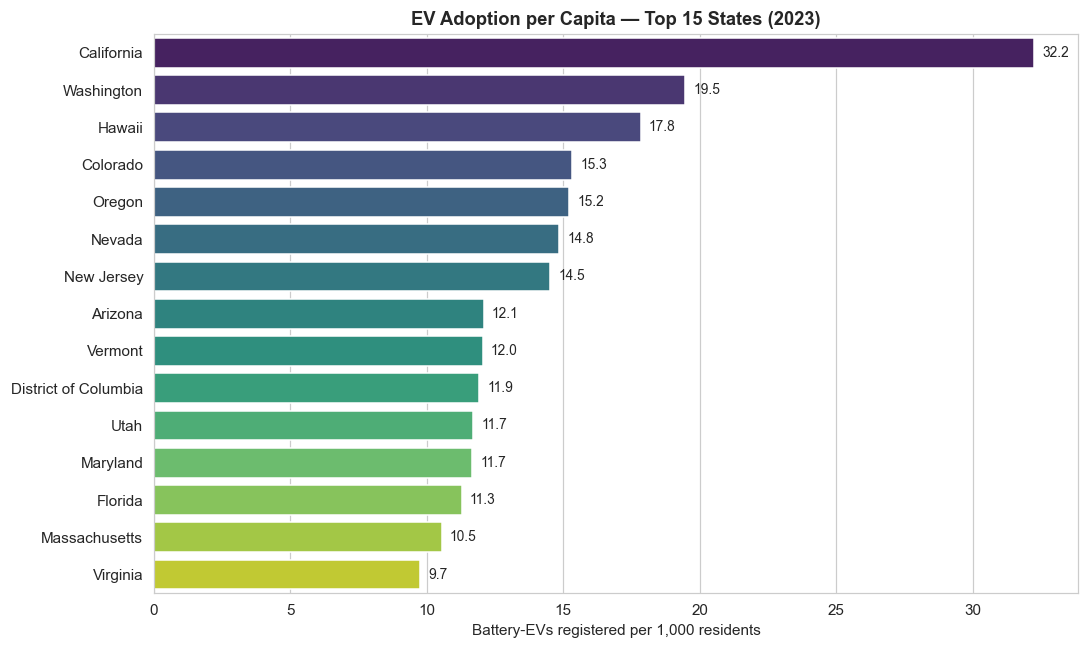

In [4]:
reg_pop = reg.merge(population, on=["State", "Year"], how="left")
reg_pop["EV per 1k"] = reg_pop["Electric (EV)"] / reg_pop["Population"] * 1000

top_pc = (reg_pop[reg_pop["Year"] == 2023]
          .sort_values("EV per 1k", ascending=False)
          .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_pc, y="State", x="EV per 1k", palette="viridis", ax=ax)
ax.set_title("EV Adoption per Capita — Top 15 States (2023)")
ax.set_xlabel("Battery-EVs registered per 1,000 residents")
ax.set_ylabel("")
for i, v in enumerate(top_pc["EV per 1k"]):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

**Insight.** California still leads per capita (~32 EVs per 1,000 people), but the normalized
view reshuffles the board: **Washington, Hawaii, Colorado, Oregon, and Nevada** all rank in the
top tier, while raw-count heavyweights **Florida and Texas drop out of the leaders entirely**.
Deep EV penetration clusters on the West Coast and in states with strong clean-energy incentives —
not simply in the most populous states.

## 3. EV share of the fleet — the 2018 → 2023 shift

Absolute growth is impressive, but EVs are still a small slice of total registrations. This view
tracks EVs as a **percentage of every registered light vehicle**, comparing 2018 with 2023 for the
states with the highest 2023 share.

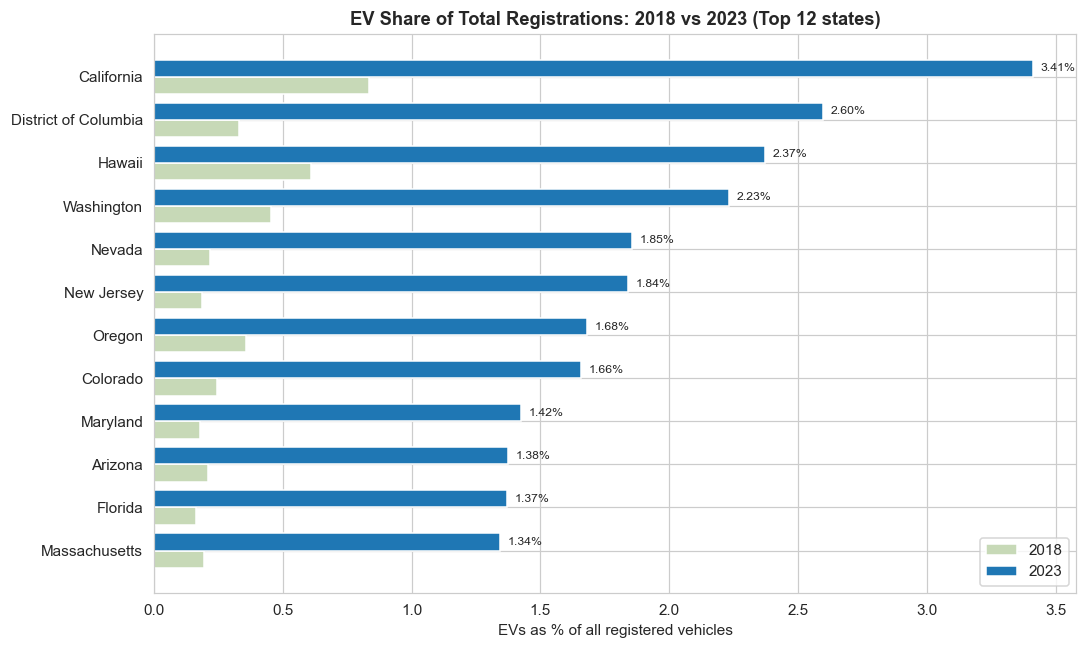

In [5]:
share = reg[reg["Year"].isin([2018, 2023])][["State", "Year", "EV Share %"]]
share_wide = share.pivot(index="State", columns="Year", values="EV Share %")
share_wide = share_wide.sort_values(2023, ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(share_wide))
ax.barh(y + 0.2, share_wide[2018], height=0.4, label="2018", color="#c7d9b7")
ax.barh(y - 0.2, share_wide[2023], height=0.4, label="2023", color="#1f77b4")
ax.set_yticks(y); ax.set_yticklabels(share_wide.index)
ax.invert_yaxis()
ax.set_xlabel("EVs as % of all registered vehicles")
ax.set_title("EV Share of Total Registrations: 2018 vs 2023 (Top 12 states)")
ax.legend()
for i, (a, b) in enumerate(zip(share_wide[2018], share_wide[2023])):
    ax.text(b + 0.03, i - 0.2, f"{b:.2f}%", va="center", fontsize=8)
plt.tight_layout(); plt.show()

**Insight.** Even the leading states sit **below ~3.5%** EV share in 2023 — but the *trajectory*
is steep. California roughly **6×'d** its share (0.9% → 3.4%), and every top state multiplied its EV
penetration several times over in just five years. The takeaway for stakeholders: the market is
early-stage, and the runway for continued growth is enormous.

## 4. Gasoline prices vs EV adoption

Do drivers turn to EVs when gas gets expensive? The EIA file is **monthly** (1993–2024) while
registrations are **annual (2018–2023)**, so we first collapse gas prices to an annual mean and
**restrict both series to the same 2018–2023 window** before comparing them.

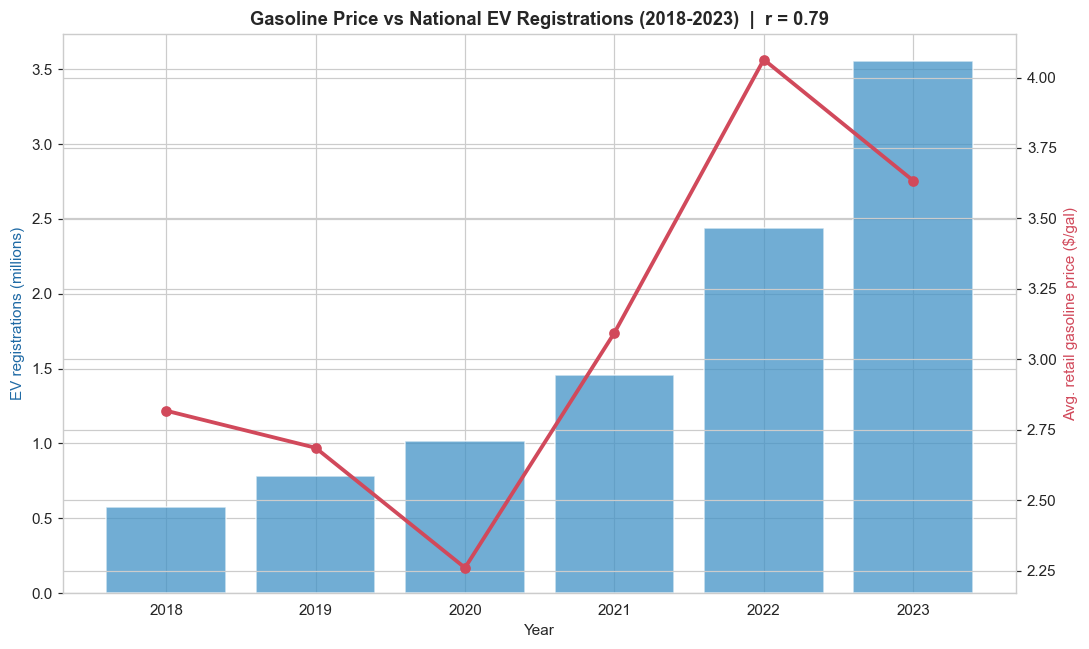

Pearson correlation: 0.786


In [6]:
gas["Year"] = pd.to_datetime(gas["Month"], format="%b %Y").dt.year
gas_annual = (gas[(gas["Year"] >= 2018) & (gas["Year"] <= 2023)]
              .groupby("Year")["Price"].mean())

assert list(gas_annual.index) == list(national_ev.index), "year windows must match"

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(national_ev.index, national_ev.values / 1e6, color="#4292c6", alpha=0.75,
        label="National EV registrations")
ax1.set_ylabel("EV registrations (millions)", color="#1f6aa5")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(gas_annual.index, gas_annual.values, color="#d1495b", marker="o", lw=2.5,
         label="Avg gas price")
ax2.set_ylabel("Avg. retail gasoline price ($/gal)", color="#d1495b")

r = np.corrcoef(gas_annual.values, national_ev.values)[0, 1]
ax1.set_title(f"Gasoline Price vs National EV Registrations (2018-2023)  |  r = {r:.2f}")
plt.tight_layout(); plt.show()
print(f"Pearson correlation: {r:.3f}")

**Insight.** The two series move together (**r ≈ 0.79**): EV registrations climbed alongside the
2021–2022 gas-price spike. But both variables also trend upward with time, so this is **correlation,
not proven causation** — rising prices, expanding model availability, incentives, and improving
infrastructure all pushed in the same direction. Still, the co-movement is consistent with fuel cost
being one lever on adoption.

## 5. Which states are growing fastest?

Leaders aren't always the fastest movers. Compound annual growth rate (CAGR) of EV registrations
from 2018 to 2023 highlights where adoption is *accelerating* — often smaller-base states catching
up. We restrict to states with at least 1,000 EVs in 2018 so tiny-base noise doesn't dominate.

C:\Users\mail2\AppData\Local\Temp\ipykernel_2912\1367807710.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cagr.values, y=cagr.index, palette="rocket", ax=ax)


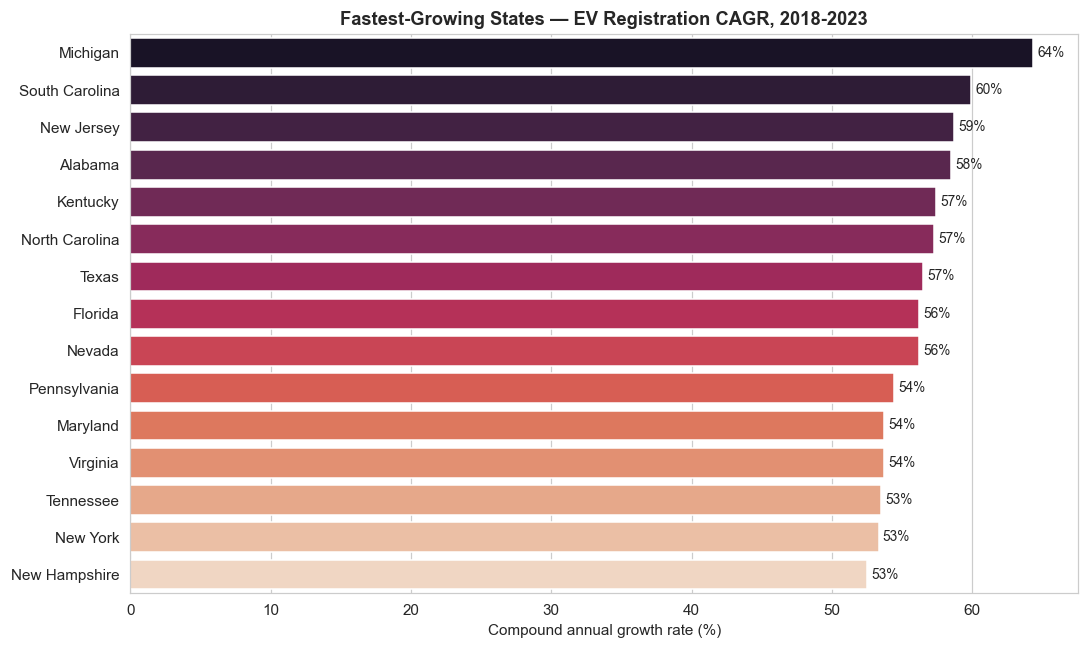

In [7]:
base = reg[reg["Year"] == 2018].set_index("State")["Electric (EV)"]
end  = reg[reg["Year"] == 2023].set_index("State")["Electric (EV)"]
cagr = (((end / base) ** (1/5) - 1) * 100)[base >= 1000].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=cagr.values, y=cagr.index, palette="rocket", ax=ax)
ax.set_title("Fastest-Growing States — EV Registration CAGR, 2018-2023")
ax.set_xlabel("Compound annual growth rate (%)")
ax.set_ylabel("")
for i, v in enumerate(cagr.values):
    ax.text(v + 0.3, i, f"{v:.0f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()

**Insight.** The fastest growers — **Michigan, South Carolina, New Jersey, Alabama, Kentucky** —
are largely *not* the established leaders. Many are Southern and Midwestern states starting from a
smaller base and compounding at **55–65% a year**. For automakers and infrastructure planners, these
are the emerging markets where demand is scaling quickest.

## 6. The national fuel-mix shift

Finally, a wide-angle view: how the mix of *newly registered* powertrains changed nationally from
2018 to 2023, grouping the many fuel types into readable categories.

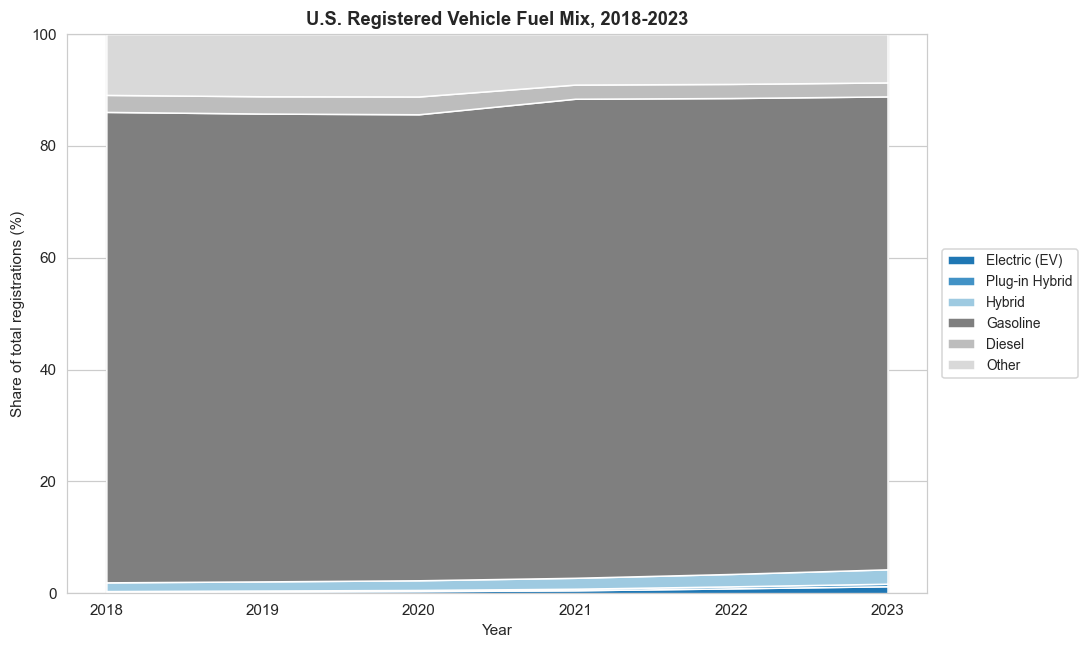

Electrified (EV+PHEV+HEV) share of registrations:
Year
2018    1.94%
2019    2.11%
2020    2.31%
2021    2.75%
2022    3.44%
2023    4.27%


In [8]:
groups = {
    "Electric (EV)": ["Electric (EV)"],
    "Plug-in Hybrid": ["Plug-In Hybrid Electric (PHEV)"],
    "Hybrid": ["Hybrid Electric (HEV)"],
    "Gasoline": ["Gasoline"],
    "Diesel": ["Diesel"],
    "Other": ["Biodiesel", "Ethanol/Flex (E85)", "Compressed Natural Gas (CNG)",
              "Propane", "Hydrogen", "Methanol", "Unknown Fuel"],
}
mix = pd.DataFrame({g: reg.groupby("Year")[cols].sum().sum(axis=1)
                    for g, cols in groups.items()})
mix_share = mix.div(mix.sum(axis=1), axis=0) * 100

# Electrified share (EV + PHEV + HEV) for the annotation
electrified = mix_share[["Electric (EV)", "Plug-in Hybrid", "Hybrid"]].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
palette = ["#1f77b4", "#4292c6", "#9ecae1", "#7f7f7f", "#bdbdbd", "#d9d9d9"]
ax.stackplot(mix_share.index, [mix_share[c] for c in mix_share.columns],
             labels=mix_share.columns, colors=palette)
ax.set_title("U.S. Registered Vehicle Fuel Mix, 2018-2023")
ax.set_ylabel("Share of total registrations (%)")
ax.set_xlabel("Year")
ax.set_ylim(0, 100)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.tight_layout(); plt.show()

print("Electrified (EV+PHEV+HEV) share of registrations:")
print(electrified.round(2).astype(str).add("%").to_string())

**Insight.** Gasoline still dominates the installed base, but the **electrified slice
(EV + plug-in + hybrid) roughly doubled** its share over the period, while diesel and the niche
alternative fuels flat-lined or shrank. The composition is shifting steadily — the fleet is early in
a transition, not at the end of one.

## 7. Key takeaways

- **Per-capita leadership ≠ raw-count leadership.** Population-adjusting elevates Washington, Hawaii,
  Colorado, and Oregon; Florida and Texas fall out of the top tier despite huge absolute numbers.
- **EVs are still a small — but fast-rising — share** of the fleet (< 3.5% even in leading states in
  2023), which signals a long growth runway rather than a saturated market.
- **Gas prices and EV adoption move together** (r ≈ 0.79), consistent with fuel cost being one driver
  of adoption, though not the only one.
- **The fastest-growing markets are emerging states** (Michigan, South Carolina, New Jersey) compounding
  at 55–65%/yr — the places to watch for the next wave of demand.
- **The fuel mix is visibly electrifying**, with the combined EV/PHEV/hybrid share roughly doubling
  from 2018 to 2023.

*These findings build directly on the original team analysis, adding a per-capita and market-share lens
using only openly available data.*